In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the data
df = pd.read_csv('20251206_matt_small_circle_accel.csv')
df.columns = df.columns.str.strip()

# print(df)
print(df['xtime [s]'])

0      228.914
1      229.014
2      229.114
3      229.214
4      229.314
        ...   
568    285.714
569    285.814
570    285.914
571    286.014
572    286.114
Name: xtime [s], Length: 573, dtype: float64


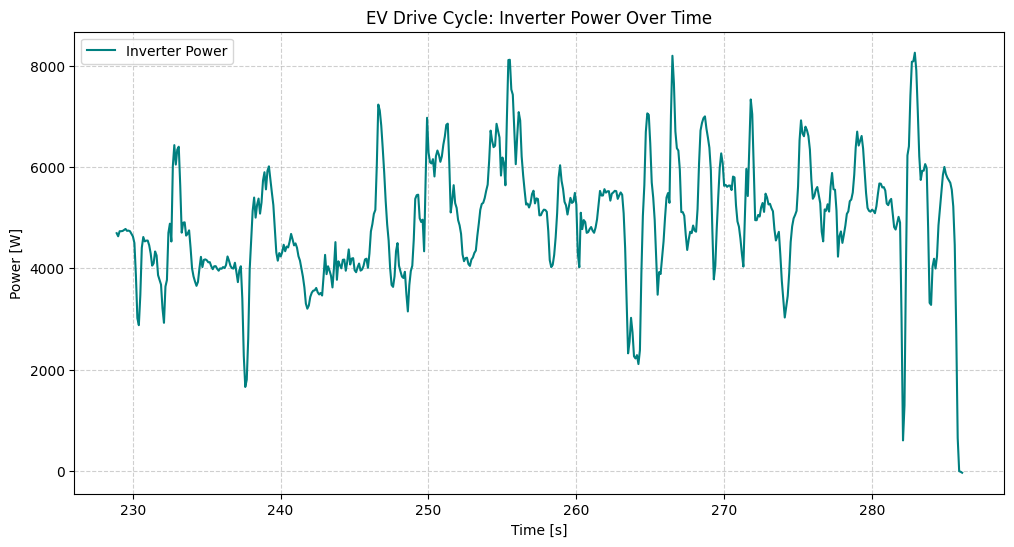

In [9]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df['xtime [s]'], df['WD_inverterPower[W]'], label='Inverter Power', color='teal')

# Formatting for a professional look
plt.title('EV Drive Cycle: Inverter Power Over Time')
plt.xlabel('Time [s]')
plt.ylabel('Power [W]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

In [11]:
## quick energy consumption calc

import numpy as np

time = df['xtime [s]'].values
power = df['WD_inverterPower[W]'].values

energy_joules = np.trapezoid(power, time)

print("Energy consumed:", energy_joules, "J")
print("Energy consumed:", energy_joules/3600, "Wh")
print("Energy consumed:", energy_joules/3.6e6, "kWh")

Energy consumed: 282517.2216 J
Energy consumed: 78.477006 Wh
Energy consumed: 0.078477006 kWh


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the power column
power_col = 'WD_inverterPower[W]'
time_col = 'xtime [s]'


In [6]:
# Calculate RMS for the WHOLE dataset
# RMS = sqrt(mean(values^2))
power_values = df[power_col]
rms_whole = np.sqrt(np.mean(power_values**2))

print(f"--- Whole Run Statistics ---")
print(f"Total Duration: {df[time_col].iloc[-1] - df[time_col].iloc[0]:.2f} seconds")
print(f"Whole Run RMS Power: {rms_whole:.2f} W ({rms_whole/1000:.2f} kW)")

--- Whole Run Statistics ---
Total Duration: 57.20 seconds
Whole Run RMS Power: 5072.37 W (5.07 kW)


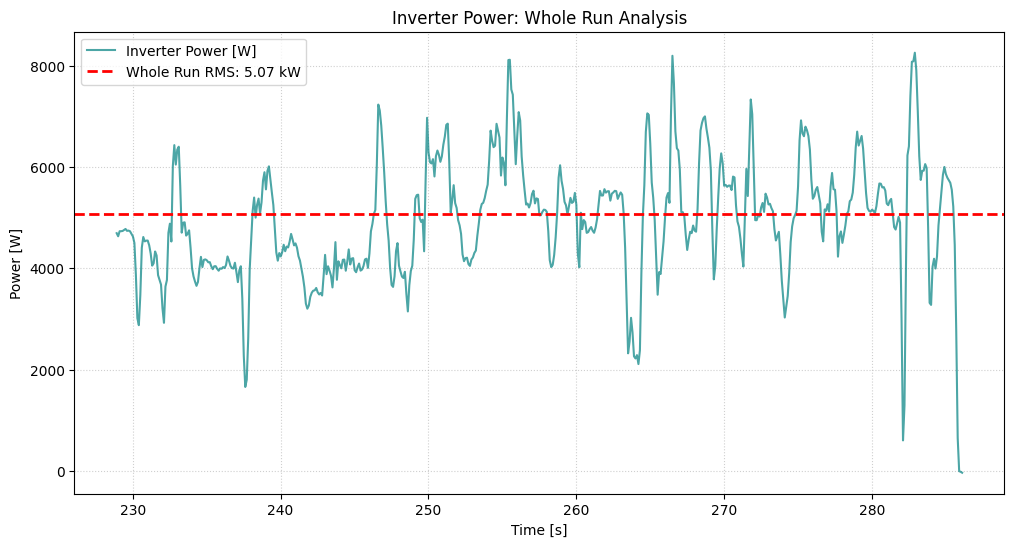

In [7]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df[time_col], df[power_col], label='Inverter Power [W]', color='teal', alpha=0.7)

# Overlay the Whole Run RMS as a horizontal line
plt.axhline(y=rms_whole, color='red', linestyle='--', linewidth=2, 
            label=f'Whole Run RMS: {rms_whole/1000:.2f} kW')

plt.title('Inverter Power: Whole Run Analysis')
plt.xlabel('Time [s]')
plt.ylabel('Power [W]')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [84]:
seg_temp_col = 'STMM_seg3ThermValAvg[?C]'

temp_values = df[seg_temp_col]

rms_whole = np.sqrt(np.mean(temp_values**2))

print(f"--- Whole Run Statistics ---")
print(f"Total Duration: {df[time_col].iloc[-1] - df[time_col].iloc[0]:.2f} seconds")
print(f"Whole Run RMS Temperature: {rms_whole:.2f} degC ({rms_whole/1000:.2f} degC)")

--- Whole Run Statistics ---
Total Duration: 211.80 seconds
Whole Run RMS Temperature: 24.22 degC (0.02 degC)


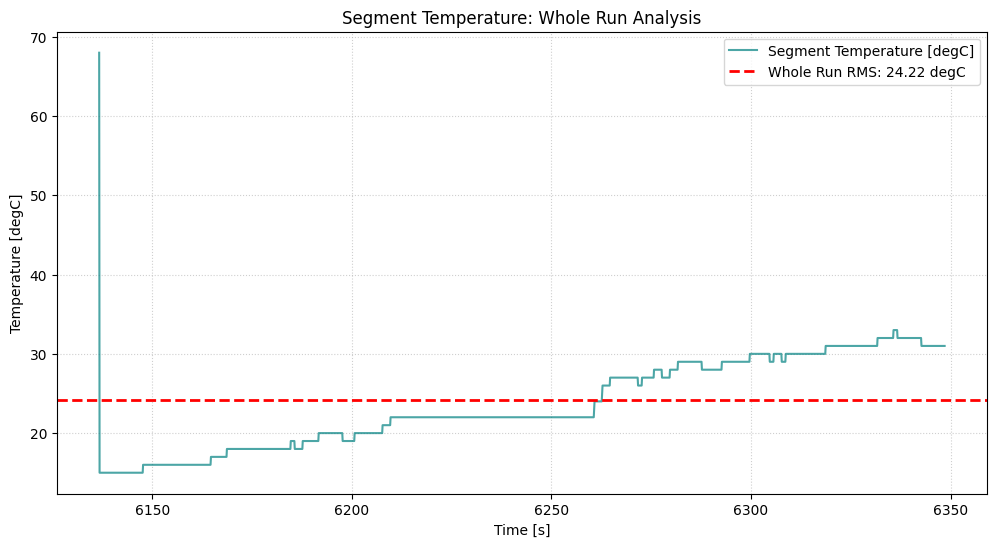

In [86]:
# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df[time_col], df[seg_temp_col], label='Segment Temperature [degC]', color='teal', alpha=0.7)

# Overlay the Whole Run RMS as a horizontal line
plt.axhline(y=rms_whole, color='red', linestyle='--', linewidth=2, 
            label=f'Whole Run RMS: {rms_whole:.2f} degC')

plt.title('Segment Temperature: Whole Run Analysis')
plt.xlabel('Time [s]')
plt.ylabel('Temperature [degC]')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()